In [ ]:
# | default_exp koopman_inference

# Yin-Yang Model Delay Coordinates with PyKoopman

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [ ]:
from ast import literal_eval

import einops
import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
import pykoopman as pk
import torch
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file, load_model, save_model
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torcheval.metrics import MulticlassAccuracy
from torchvision import datasets, transforms

from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
from learningdynamics.datasets import YinYangBinaryDataset

In [ ]:
#| export
from torcheval.metrics import MulticlassAccuracy
from torch.utils.data import DataLoader, Subset
import numpy as np
import warnings
from learningdynamics.utils import (
    getActivation,
)
import torch
import math

In [ ]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

In [ ]:
LAYER_START = 1

In [ ]:
file_path = f"../saved_weights/yinyang_start{LAYER_START}_states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_TRAJECTORIES = literal_eval(metadata["num_trajectories"])
NUM_STATES = literal_eval(metadata["num_states"])
NUM_ITERATIONS = literal_eval(metadata["num_iterations"])
NUM_STATES_OF_INTEREST = literal_eval(metadata["num_usable_states"])
data = load_file(file_path)

#### Update dataset

In [ ]:
NUM_TRAJECTORIES = 500
NUM_STATES = NUM_STATES
NUM_DELAYS = NUM_ITERATIONS-2

In [ ]:
t = np.arange(0, NUM_ITERATIONS, 1)

#### Learn Koopman Operator

In [ ]:
train_states = reshape_append_time(
    data["train_states"][:NUM_ITERATIONS, :NUM_TRAJECTORIES, :NUM_STATES]
)
test_states = reshape_append_time(data["test_states"][:NUM_ITERATIONS, :, :NUM_STATES])
observables = pk.observables.TimeDelay(delay=1, n_delays=NUM_DELAYS)

In [ ]:
# Time shift data
X = train_states[:NUM_STATES, :-1].numpy()
Y = train_states[:NUM_STATES, 1:].numpy()

In [ ]:
# regressor = pk.regression.EDMD(svd_rank=300)
regressor = pk.regression.EDMD()
# regressor = DMD(svd_rank=RANK)

dmd_model = pk.Koopman(observables=observables, regressor=regressor)
# dmd_model.fit(X.T, y=Y.T)
dmd_model.fit(train_states.numpy().T)

Koopman(observables=TimeDelay(n_delays=10), regressor=EDMD())

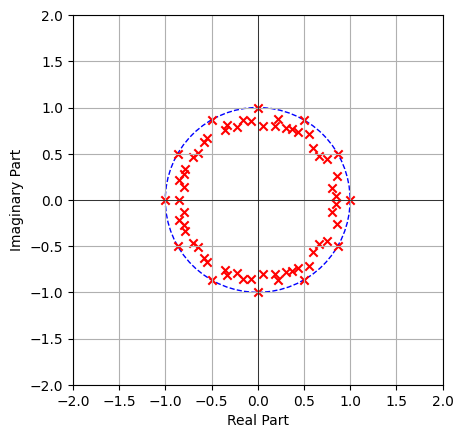

In [ ]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.diag(dmd_model.lamda)

filtered_eigenvals = koop_eigenvals[np.abs(koop_eigenvals) > 0.8]

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    filtered_eigenvals.real, filtered_eigenvals.imag, color="r", marker="x"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")

# Show the plot
plt.show()

In [ ]:
def predict_plot(states, sample, plot=True, plot_num_states=64):
    x0_td = states[
        :NUM_STATES,
        sample * NUM_ITERATIONS : (sample * NUM_ITERATIONS) + NUM_DELAYS + 1,
    ].T.numpy()

    plot_num_states = min(plot_num_states, NUM_STATES)

    Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_ITERATIONS - 1 - NUM_DELAYS)
    Xkoop = np.vstack([x0_td, Xkoop])

    if plot:
        fig, axs = plt.subplots(
            plot_num_states, 1, sharex=True, tight_layout=True, figsize=(12, 6)
        )
        for state_idx in range(0, plot_num_states):
            axs[state_idx].plot(
                t,
                states[
                    state_idx,
                    sample * NUM_ITERATIONS : sample * NUM_ITERATIONS + NUM_ITERATIONS,
                ],
                "-",
                color="b",
                label="True States",
            )
            axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
            axs[state_idx].set(ylabel=f"state {state_idx}")

        for i in range(0, plot_num_states):
            axs[i].axvline(x=t[NUM_DELAYS])

    return Xkoop


def test_error(true_states, pred_states, num_states=None):
    if num_states:
        loss = F.l1_loss(
            true_states[:num_states, -1], torch.nn.functional.relu(torch.Tensor(pred_states)).T[:num_states, -1], reduction="sum"
        )
    else:
        loss = F.l1_loss(
            true_states[:, -1], torch.nn.functional.relu(torch.Tensor(pred_states)).T[:, -1], reduction="sum"
        )
    return loss

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


102
Error: 0.5169267058372498


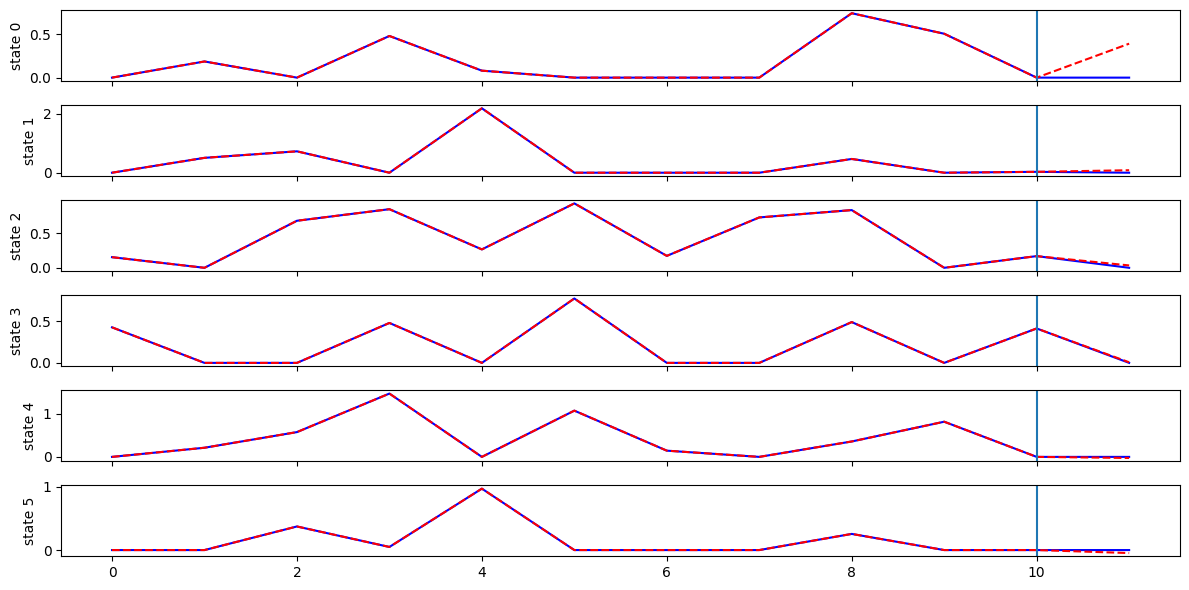

In [ ]:
SAMPLE = np.random.choice(NUM_TRAJECTORIES)
Xkoop = predict_plot(train_states, 0, plot_num_states=NUM_STATES_OF_INTEREST)
error = test_error(
    true_states=train_states[
        :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
    ],
    pred_states=Xkoop,
    num_states=NUM_STATES_OF_INTEREST,
)

print(SAMPLE)
print(f"Error: {error.item()}")

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


435
Error: 0.155472531914711


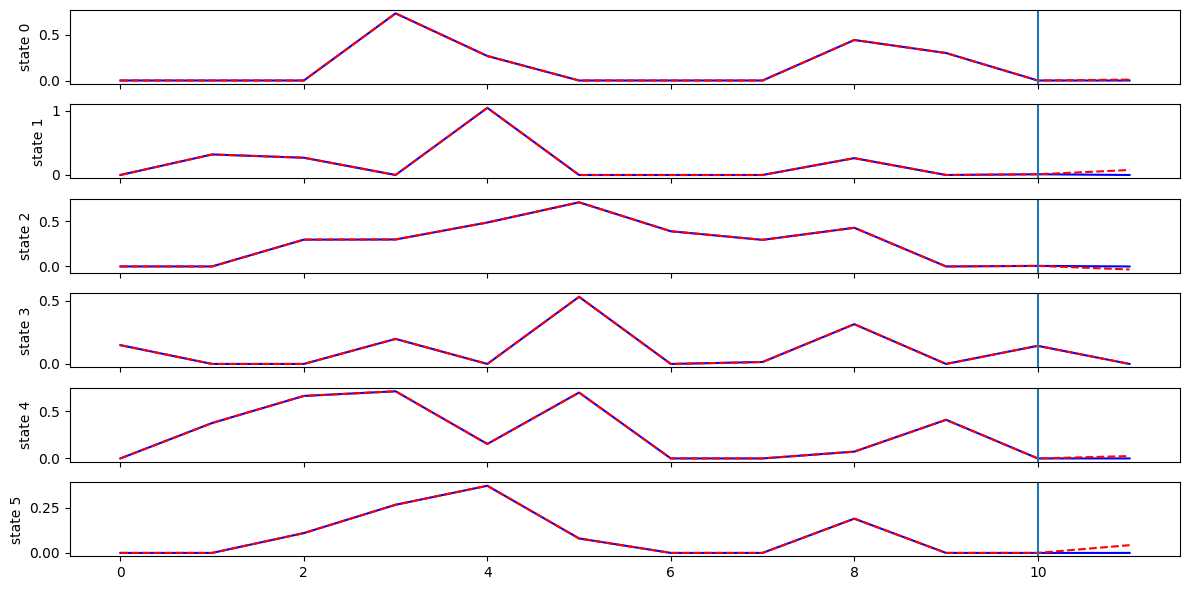

In [ ]:
SAMPLE = np.random.choice(1000)
Xkoop = predict_plot(test_states, SAMPLE, plot_num_states=NUM_STATES_OF_INTEREST)
error = test_error(
    true_states=test_states[
        :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
    ],
    pred_states=Xkoop,
    num_states=NUM_STATES_OF_INTEREST,
)

print(SAMPLE)
print(f"Error: {error.item()}")

In [ ]:
# import warnings

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     errors = []
#     for SAMPLE in range(1000):
#         Xkoop = predict_plot(test_states, SAMPLE, plot=False, plot_num_states=NUM_STATES_OF_INTEREST)
#         error = test_error(
#             true_states=test_states[
#                 :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
#             ],
#             pred_states=Xkoop,
#             num_states = NUM_STATES_OF_INTEREST,
#         )
#         errors.append(error)

#     errors = torch.stack(errors)
#     mean = torch.mean(errors)
#     std = torch.std(errors)
#     print(f"Mean Error {mean.item()}, Standard Dev {std.item()}")

Mean Error 0.503635823726654, Standard Dev 0.4274963140487671


In [ ]:
#| export

def inference_with_koopman(
    nn_model,
    dmd_model,
    test_set,
    layer_start,
    num_iterations,
    num_delays,
    num_usable_states,
    test_size=None,
):
    # Build subset
    if test_set is not None:
        subset = Subset(test_set, torch.arange(0, test_size))
    else:
        subset = test_set
    dataloader = DataLoader(dataset=subset, shuffle=True, batch_size=1000)

    hooks = []
    activation_dict = {}
    nn_model.eval()

    # Attach hooks to scaled model
    for i in range(layer_start, layer_start + (num_iterations - 1) * 2, 2):
        hooks.append(
            nn_model.features[i].register_forward_hook(
                getActivation(f"layer_{i}", activation_dict)
            )
        )

    metric = MulticlassAccuracy()

    num_supplements = math.ceil((num_delays - num_iterations + 2) / num_iterations)

    for batch in dataloader:
        # Unwrap batch
        input, target = batch
        _ = nn_model(input)

        # Grab activation
        out = torch.stack(list(activation_dict.values()))  # shape = i,t,s

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            koop_list = []
            for traj in range(out.shape[1]):
                # if num_supplements > 0:
                #     sample_id = np.random.choice(1000)
                #     pair_traj = train_states[
                #         :, sample_id * num_iterations : (sample_id * num_iterations) + num_supplements * num_iterations
                #     ].T.numpy()
                #     traj_in = np.concatenate((pair_traj, out[:, traj, :].numpy()), axis=0)

                traj_in = out[:num_delays+1, traj, :].numpy()

                Xkoop = dmd_model.simulate(
                    traj_in,
                    n_steps=(num_iterations * (num_supplements + 1)) - 1 - num_delays,
                )

                koop_list.append(torch.from_numpy(Xkoop)[-1:, :])

        koop_out = torch.cat(koop_list)[:, :num_usable_states]
        # koop_out = torch.nn.functional.relu(koop_out)

        # Feed through the rest
        for i in range(
            layer_start + (num_iterations - 1) * 2 + 1, len(nn_model.features)
        ):
            koop_out = nn_model.features[i](koop_out)

        metric.update(koop_out, target.squeeze())

    return koop_out, metric.compute()

In [ ]:
# Load model
file_path = f"../saved_weights/yinyang_start{LAYER_START}_scaled_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
scaled_model = MLP(
    config=literal_eval(metadata["config"]),
    nonlinearity=metadata["nonlinearity"],
)
_ = load_model(scaled_model, file_path, device="cuda:0")

In [ ]:
NUM_SAMPLES = 1000
test_set = YinYangBinaryDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=123)